In [4]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [16]:
# Seasonal time series plotting for aerosol data
def seasonal_timeseries(files, aerosols, time_range=None):
    seasons = xr.groupers.SeasonResampler(['DJF', 'MAM', 'JJA', 'SON'])
    plotting = []
    colors = list(mcolors.TABLEAU_COLORS.keys())
    
    for f in files:
        with xr.open_dataset(f) as ds:
            try:
                ds.lat
                ds.lon
                ds.time
            except:
                raise ValueError('The provided file does not have all necessary coordinates. Please ensure it has latitude, longitude, and time coordinates')

            if time_range != None:
                start = str(time_range[0])
                end = str(time_range[1])
                ds = ds.sel(time=slice(start, end))
            else:
                start = str((ds['date'].values)[0])[:4]
                end = str((ds['date'].values)[len(ds['date'])-1])[:4]
            
            ds_seasonal = ds.resample({'time':seasons}).mean()
            ds_global = ds_seasonal.mean(dim=['lat','lon'])
            plotting.append(ds_global)
            
    fig = plt.figure()
    ax = plt.axes()
    for i in range(len(plotting)):
        plt.plot(plotting[i].time, plotting[i].bb, label=aerosols[i], color=colors[i]) 
    plt.legend()
    plt.xlabel('Time')
    plt.ylabel('molecules/cm²/s')
    plt.title(f'Seasonal Global Concentration of {', '.join(a for a in aerosols)}, {start} - {end}')

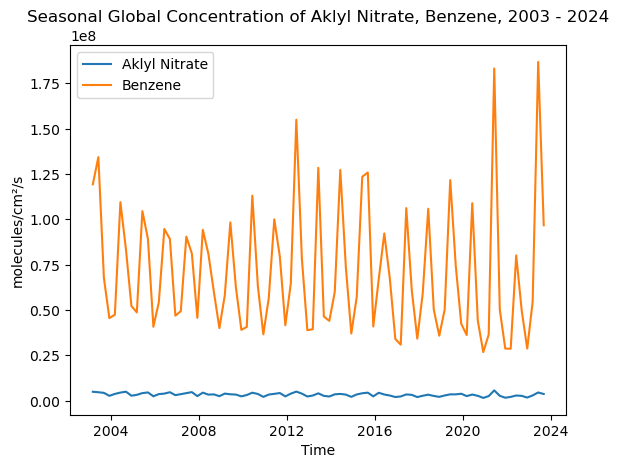

In [17]:
seasonal_timeseries(['/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/gfas4htap-moz_ALKNIT_bb_2003-2023_f09_c20260306.nc',
                     '/glade/work/ekeefe/research_code/gfas4htap_fire_emissions/gfas4htap-moz_BENZENE_bb_2003-2023_f09_c20260306.nc'],
                    ['Aklyl Nitrate', 'Benzene'])